## Data Preprocessing and EDA

In [2]:
# Import Data

import pandas as pd
import numpy as np

df = pd.read_csv("../data/train.csv", parse_dates=["date"])

df.head()
df.info()
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
Shape: (3000888, 6)


In [3]:
# Checking the data
print("Missing values:\n", df.isna().sum())
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Number of stores:", df["store_nbr"].nunique())
print("Number of product families:", df["family"].nunique())


Missing values:
 id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Number of stores: 54
Number of product families: 33


This dataset is too big to process, so we willl forecast total sales per store per day.

In [4]:
# Group by store and date to get total sales per store per day
df_store = df.groupby(["date", "store_nbr"])\
             .agg({
                 "sales": "sum",
                 "onpromotion": "sum"
             })\
             .reset_index()
print("The first 5 rows of total sales per store per day:" + "\n", df_store.head())
print("\n")
print("The last 5 rows of total sales per store per day:" + "\n", df_store.tail())

The first 5 rows of total sales per store per day:
         date  store_nbr  sales  onpromotion
0 2013-01-01          1    0.0            0
1 2013-01-01          2    0.0            0
2 2013-01-01          3    0.0            0
3 2013-01-01          4    0.0            0
4 2013-01-01          5    0.0            0


The last 5 rows of total sales per store per day:
             date  store_nbr         sales  onpromotion
90931 2017-08-15         50  16879.121004          150
90932 2017-08-15         51  20154.559000          127
90933 2017-08-15         52  18600.046000          142
90934 2017-08-15         53   8208.189000          114
90935 2017-08-15         54  12666.858000          204


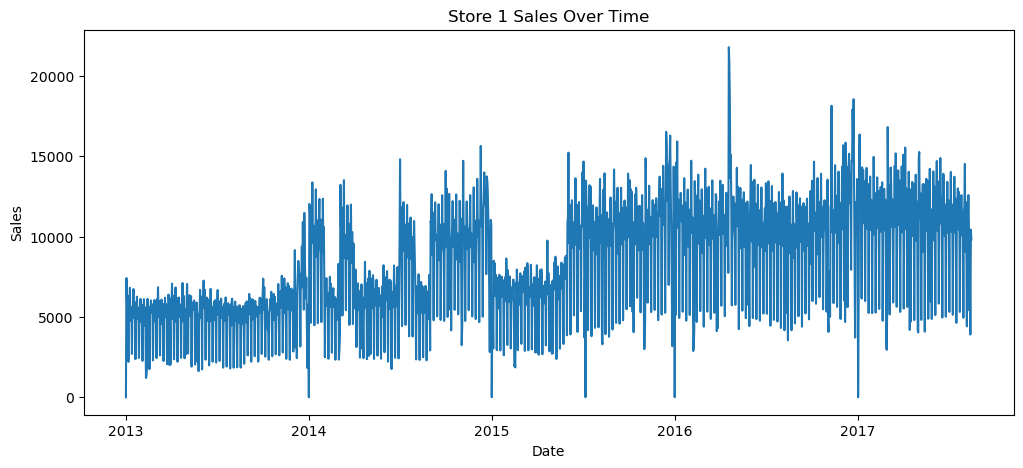

In [5]:
# Quick visualization of 1 Store
import matplotlib.pyplot as plt

store_1 = df_store[df_store["store_nbr"] == 1]

plt.figure(figsize=(12,5))
plt.plot(store_1["date"], store_1["sales"])
plt.title("Store 1 Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [ ]:
# Export the data
%store df_store

Stored 'df_store' (DataFrame)
